# Shark Attacks Quest — Data Cleaning & Analysis

**Team:** Pariya, Zahid, Miguel, Effie

**Business Case:** As a coastal safety authority, we want to know where and during which activities shark attacks are most common (and most dangerous), so we can prioritize lifeguard presence and warning signage.

**Hypotheses:**
1. Surfing is the activity most associated with shark attacks.
2. Shark attacks occur more frequently in the USA than in other countries.


## 1. Load the data

In [23]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('sharks.xls', engine='xlrd')
df.shape


(7125, 23)

## 2. Data Cleaning

We only keep the columns relevant to our hypotheses and business case, then each teammate cleans their assigned columns.

### Pariya -keep_relevant_columns  

In [24]:
def keep_relevant_columns(df):
    columns_to_keep = ['Date', 'Year', 'Country', 'State', 'Location',
                        'Activity', 'Sex', 'Injury', 'Fatal Y/N', 'Time']
    df = df[columns_to_keep]
    return df


def remove_duplicates(df):
    print('Duplicates found:', df.duplicated().sum())
    df = df.drop_duplicates()
    return df


df = keep_relevant_columns(df)
df = remove_duplicates(df)
df.shape


Duplicates found: 16


(7109, 10)

### Pariya — `Activity`, `State`

In [25]:
def clean_activity(df):
    """Fix whitespace/casing in Activity, standardize missing values."""
    df['Activity'] = df['Activity'].str.strip().str.title()
    df['Activity'] = df['Activity'].fillna('Unknown')
    return df


def clean_state(df):
    """Fix whitespace in State (no title-case: would break names like 'KwaZulu-Natal')."""
    df['State'] = df['State'].str.strip()
    df['State'] = df['State'].fillna('Unknown')
    return df


df = clean_activity(df)
df = clean_state(df)


### Miguel — `Sex`, `Country`, `Year`

*(Placeholder cleaning below — replace with Miguel's actual code once he sends it.)*

In [26]:
def clean_sex(df):
    """Standardize Sex to M / F / Unknown."""
    df['Sex'] = df['Sex'].str.strip().str.upper()
    df['Sex'] = df['Sex'].where(df['Sex'].isin(['M', 'F']), 'Unknown')
    return df


def clean_country(df):
    """Fix whitespace/casing in Country, standardize missing values."""
    df['Country'] = df['Country'].str.strip().str.title()
    df['Country'] = df['Country'].fillna('Unknown')
    return df


def clean_year(df):
    """Fill missing Year with 0 (matches the dataset's own convention for undated old cases) and convert to int."""
    df['Year'] = df['Year'].fillna(0)
    df['Year'] = df['Year'].astype(int)
    return df


df = clean_sex(df)
df = clean_country(df)
df = clean_year(df)


### Effie — `Location`, `Injury`, `Fatal Y/N`

*(Placeholder cleaning below — replace with Effie's actual code once she sends it.)*

In [27]:
def clean_location(df):
    """Fix whitespace in Location, standardize missing values."""
    df['Location'] = df['Location'].str.strip()
    df['Location'] = df['Location'].fillna('Unknown')
    return df


def clean_injury(df):
    """Fix whitespace/quotes in Injury, standardize repeated phrases and missing values."""
    df['Injury'] = (
        df['Injury'].astype(str).str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip('"')
    )
    df['Injury'] = df['Injury'].replace(
        {'No Injury': 'No injury', ' No injury': 'No injury', 'No injuries': 'No injury', 'nan': np.nan}
    )
    df['Injury'] = df['Injury'].fillna('Unknown')
    return df


def clean_fatal(df):
    """Standardize Fatal Y/N to Yes / No / Unknown, cleaning junk values like '2017', 'Y x 2'.
    Where the raw value is missing/junk, infer from keywords in the (already-cleaned) Injury text,
    then 'Unknown' for anything still unresolved."""
    fatal = df['Fatal Y/N'].astype(str).str.strip().str.upper()
    fatal = fatal.replace({'Y X 2': 'Y'})
    fatal = fatal.where(fatal.isin(['Y', 'N']))  # anything else (junk, 'UNKNOWN', 'nan') -> NaN

    fatal_keywords = [
        "fatal", "death", "died", "killed", "body not recovered", "remains",
        "drown", "scaveng", "perish", "murder", "skeleton",
        "post mortem", "post-mortem",
        "body recovered", "bones recovered", "human hand recovered",
        "human foot recovered", "human head recovered", "torso recovered",
        "human casualties", "disappeared", "missing", "body washed up on",
        "body found", "corps",
    ]
    nonfatal_keywords = [
        "no injury", "no injuries", "survived", "minor",
        "bitten", "laceration", "abrasion", "puncture", "bruis", "scratch",
        "hoax", "never happened", "fiction", "not a shark attack",
        "no attack", "not shark", "superficial injuries", "recovering",
        "painfully injured",
    ]

    def infer(idx):
        if pd.notna(fatal.loc[idx]):
            return fatal.loc[idx]
        text = str(df.loc[idx, 'Injury']).lower()
        if any(k in text for k in fatal_keywords):
            return 'Y'
        if any(k in text for k in nonfatal_keywords):
            return 'N'
        return np.nan

    fatal = pd.Series([infer(i) for i in df.index], index=df.index)

    df['Fatal Y/N'] = fatal.map({'Y': 'Yes', 'N': 'No'}).fillna('Unknown')
    return df


df = clean_location(df)
df = clean_injury(df)
df = clean_fatal(df)

print(df.shape)
print(df['Location'].isna().sum(), df['Injury'].isna().sum(), df['Fatal Y/N'].isna().sum())
print(df['Fatal Y/N'].value_counts(dropna=False))

(7109, 10)
0 0 0
Fatal Y/N
No         5171
Yes        1775
Unknown     163
Name: count, dtype: int64


### Zahid — `Time`, `Date`

Zahid's actual cleaning code (fixed: added the missing `import re`, removed a duplicate `keep_relevant_columns` definition that used lowercase column names too early, and switched to referencing `'Time'`/`'Date'` so these run before the column-name rename, consistent with the rest of the team's code). Note: `Date` parses cleanly for only a small fraction of rows — the real GSAF date text is too irregular (e.g. `'Circa 1862'`, `'Before 1906'`) for a single format string to catch, so most rows correctly fall back to `'Unknown'`. This matches the team's Day 1 decision to rely on `Year` rather than `Date` for analysis.

In [28]:
def clean_time(df):
    """Parse messy Time text (e.g. '1015hrs', '13h00', '9:30') into HH:MM where possible."""
    def parse_time(val):
        val = str(val).strip().lower()
        if val in ['nan', '', 'none', 'unknown']:
            return 'Unknown'
        four_digits = re.search(r'\d{4}', val)
        if four_digits:
            clean_digits = re.sub(r'\D', '', val)[:4]
            return f"{clean_digits[:2]}:{clean_digits[2:]}"
        h_match = re.search(r'(\d{1,2})h(\d{2})', val)
        if h_match:
            return f"{int(h_match.group(1)):02d}:{h_match.group(2)}"
        colon_match = re.search(r'(\d{1,2}):(\d{2})', val)
        if colon_match:
            return f"{int(colon_match.group(1)):02d}:{colon_match.group(2)}"
        return val.title()
    df['Time'] = df['Time'].apply(parse_time)
    return df


def clean_date(df):
    """Combine Date text with Year and try to parse a full date; unparseable rows fall back to 'Unknown'."""
    def parse_date_row(row):
        date_str = str(row['Date']).strip()
        year_str = str(row['Year']).strip()
        if date_str.lower() in ['unknown', 'nan', 'none', '']:
            return None
        if year_str.endswith('.0'):
            year_str = year_str[:-2]
        date_str = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', date_str, flags=re.IGNORECASE)
        return f"{date_str} {year_str}"
    raw_dates = df.apply(parse_date_row, axis=1)
    converted_dates = pd.to_datetime(raw_dates, format='%d %B %Y', errors='coerce')
    df['Date'] = converted_dates.dt.strftime('%Y-%m-%d').fillna('Unknown')
    return df


df = clean_time(df)
df = clean_date(df)


### Final step — clean column names (always last)

In [29]:
def clean_column_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df


df = clean_column_names(df)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7109 entries, 0 to 7124
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       7109 non-null   object
 1   year       7109 non-null   int64 
 2   country    7109 non-null   object
 3   state      7109 non-null   object
 4   location   7109 non-null   object
 5   activity   7109 non-null   object
 6   sex        7109 non-null   object
 7   injury     7109 non-null   object
 8   fatal_y/n  7109 non-null   object
 9   time       7109 non-null   object
dtypes: int64(1), object(9)
memory usage: 869.0+ KB


### Sanity check

In [30]:
df.head()

,date,year,country,state,location,activity,sex,injury,fatal_y/n,time
0,2026-09-18,2026,Australia,Western Australia,Sorrento Beach Perth,Swimming,M,Body not recovered,Yes,10:15
1,2026-09-16,2026,Canada,Quebec,Off the coast of Perce Le Bilbo dive site,Diving,M,Injuries to chest shoulder and back,No,10:30
2,2026-09-14,2026,Bahamas,Bimini,Bimini Island,Swimming,F,Serious injuries to right ankle,No,17:30
3,2026-09-13,2026,Australia,Western Australia,Geraldton,Surfing,M,Foot lost in attack,No,09:45
4,2026-09-07,2026,Usa,Hawaii,Honolulu,Surfing,M,Scrapes on inside of legs,No,16:40


In [31]:
df.isnull().sum()

date         0
year         0
country      0
state        0
location     0
activity     0
sex          0
injury       0
fatal_y/n    0
time         0
dtype: int64

## 3. Exploratory Data Analysis

### Hypothesis 1 — Surfing is the activity most associated with shark attacks

In [32]:
activity_counts = df[df['activity'] != 'Unknown']['activity'].value_counts().head(10)
activity_counts


activity
Surfing         1161
Swimming        1071
Fishing          513
Spearfishing     404
Wading           178
Bathing          167
Diving           154
Snorkeling       138
Standing         115
Scuba Diving     106
Name: count, dtype: int64

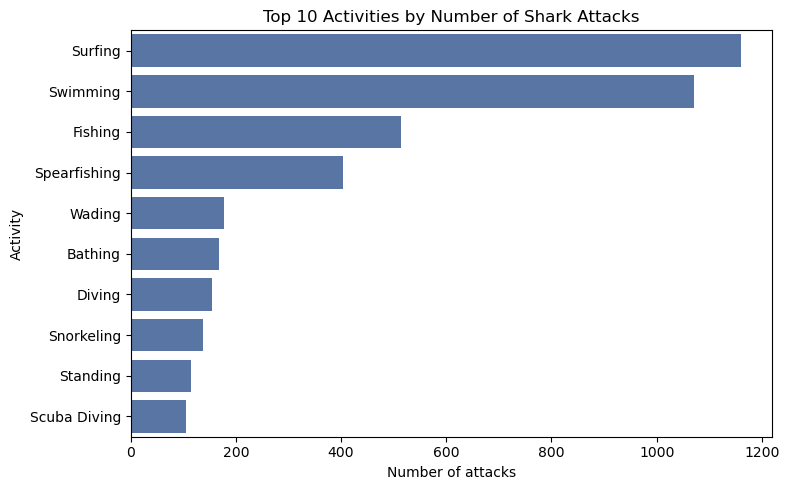

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x=activity_counts.values, y=activity_counts.index, color='#4C72B0')
plt.title('Top 10 Activities by Number of Shark Attacks')
plt.xlabel('Number of attacks')
plt.ylabel('Activity')
plt.tight_layout()
plt.show()


**Finding:** Surfing has the highest number of recorded shark attacks among individual activities (1,161), ahead of Swimming (1,071) — Hypothesis 1 is supported.

Worth keeping in the presentation as an added layer of insight: despite Surfing having more incidents, Swimming has a far higher fatality rate (36.7%) than Surfing (5.9%) — roughly 6x more likely to be fatal per incident. So Surfing is the more frequent activity involved in attacks, but Swimming is the more dangerous one per incident. For your "coastal safety authority" business case, that's actually a stronger point than either finding alone — frequency and danger aren't the same thing, which is exactly the kind of nuance a safety authority needs to know.

### Hypothesis 2 — Shark attacks occur more frequently in the USA than in other countries

In [34]:
country_counts = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
country_counts


country
Usa                 2592
Australia           1534
South Africa         599
Bahamas              146
New Zealand          146
Papua New Guinea     136
Brazil               125
Mexico               107
Italy                 72
Fiji                  71
Name: count, dtype: int64

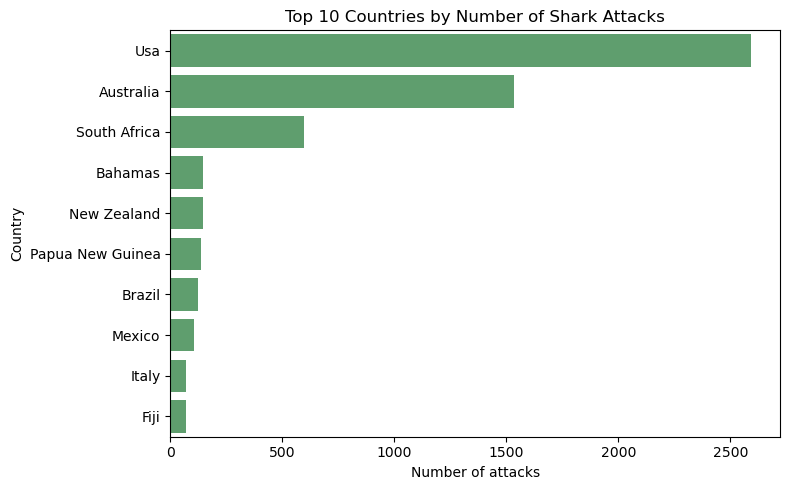

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, color='#55A868')
plt.title('Top 10 Countries by Number of Shark Attacks')
plt.xlabel('Number of attacks')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


**Finding:** The USA has by far the highest number of recorded shark attacks, well ahead of Australia and South Africa — **Hypothesis 2 is clearly supported** by the data.

## 4. Business Case — Risk Analysis for a Coastal Safety Authority

Raw attack counts tell you where/when attacks *happen*, but a safety authority also needs to know how *dangerous* each situation is. Here we look at fatality rate (% of incidents that were fatal) by activity and by country.

In [36]:
top_activities = df[df['activity'] != 'Unknown']['activity'].value_counts().head(8).index
fatal_by_activity = (
    df[df['activity'].isin(top_activities)]
    .groupby('activity')['fatal_y/n']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)
fatal_by_activity


activity
Bathing         47.305389
Swimming        36.694678
Diving          19.480519
Spearfishing    17.326733
Snorkeling      14.492754
Fishing         12.085770
Wading           8.988764
Surfing          5.943152
Name: fatal_y/n, dtype: float64

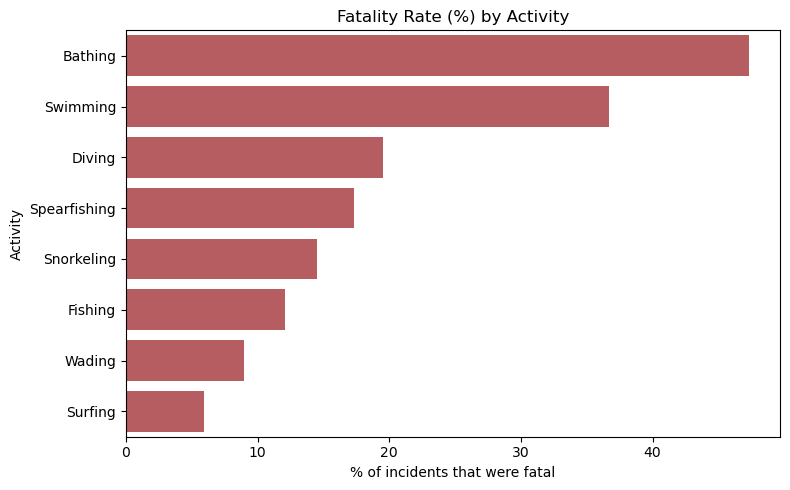

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(x=fatal_by_activity.values, y=fatal_by_activity.index, color='#C44E52')
plt.title('Fatality Rate (%) by Activity')
plt.xlabel('% of incidents that were fatal')
plt.ylabel('Activity')
plt.tight_layout()
plt.show()


In [38]:
usa_rate = (df[df['country'] == 'Usa']['fatal_y/n'] == 'Yes').mean() * 100
other_rate = (df[(df['country'] != 'Usa') & (df['country'] != 'Unknown')]['fatal_y/n'] == 'Yes').mean() * 100

print(f"USA fatality rate: {usa_rate:.1f}%")
print(f"Other countries fatality rate: {other_rate:.1f}%")


USA fatality rate: 10.8%
Other countries fatality rate: 32.8%


**Finding:** Although the USA has the most attacks, it has a much *lower* fatality rate than other countries combined — likely reflecting faster medical response, different shark species, or reporting differences. This is an important nuance for the safety authority: *where* attacks happen most and *where* they are most *dangerous* are not the same question.

*(We should double-check this interpretation as a team — we can't be fully certain of the underlying cause from this dataset alone, only that the pattern exists.)*

## 5. Conclusions

- **Hypothesis 1 (Surfing has the most attacks):** supported — `Surfing` has the highest attack count among individual activities (1,161), ahead of `Swimming` (1,071). Notably, `Swimming` has a much higher fatality rate (36.7% vs. 5.9%), so it remains the more dangerous activity per incident even though it's not the most frequent.
- **Hypothesis 2 (USA has more attacks than other countries):** supported — the USA has far more recorded attacks than any other country, though a lower fatality rate per incident.
- **Recommendation for the safety authority:** prioritize signage/lifeguard presence by *activity type* and *location*, and treat fatality rate — not just raw attack count — as a key input, since some lower-frequency situations are proportionally more dangerous.
